# Individual assignement (Max DEFEZ)

Import relevant librairies

In [59]:
import os, sys
import numpy as np
import gymnasium as gym
import time
from agents import MonteCarloControlAgent, SarsaLambdaAgent
import utils
from text_flappy_bird_gym.envs.text_flappy_bird_env_simple import TextFlappyBirdEnvSimple
import matplotlib.pyplot as plt

np.random.seed(13)

## First, we define a classical environment and train both agents on.

In [61]:
# Train both agents

env = gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 4)

num_episode = 25_000

obs, _ = env.reset()
agent_mc = MonteCarloControlAgent(action_space_shape = env.action_space.n, alpha = 0.005, gamma=0.99, epsilon=0.8)
agent_mc.train(env = env, num_episodes = num_episode)

obs, _ = env.reset()
agent_sarsa = SarsaLambdaAgent(action_space_shape = env.action_space.n, gamma=0.99, alpha=0.005, epsilon=0.7, lam=0.9)
agent_sarsa.train(env = env, num_episodes = num_episode)

Training SARSA: 100%|██████████| 25000/25000 [00:14<00:00, 1713.28it/s]


### Test the agent (on the same env) and plot the states' values

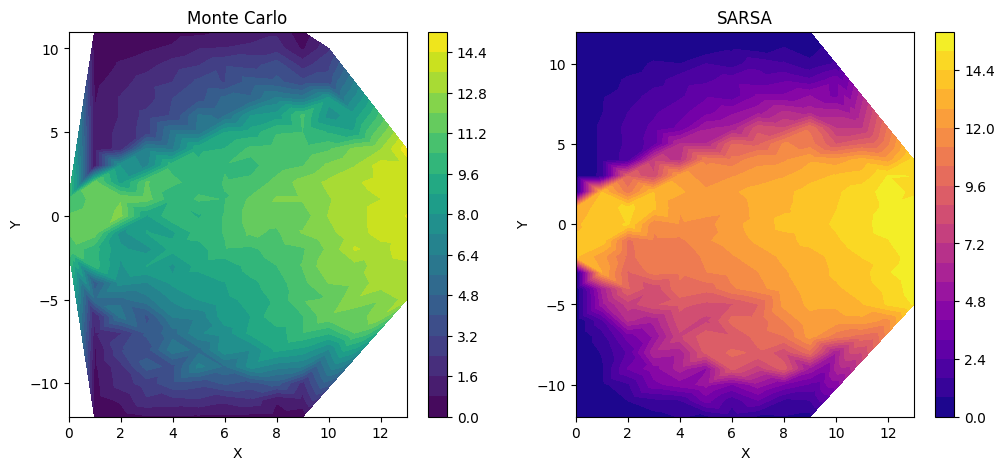

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

c1 = utils.plot_heatmap_from_Q(agent_mc.Q, ax1, cmap='viridis')
c2 = utils.plot_heatmap_from_Q(agent_sarsa.Q, ax2, cmap='plasma')

ax1.set_title("Monte Carlo")
ax2.set_title("SARSA")

fig.colorbar(c1, ax=ax1)
fig.colorbar(c2, ax=ax2)

plt.show()

Show average score and histogram of scores.

Testing:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing: 100%|██████████| 1000/1000 [00:03<00:00, 259.18it/s]


Mean score for MC : 190.855
Mean score for SARSA : 629.52
STD for MC : 182.1595947925884
STD for SARSA : 546.9548149527527


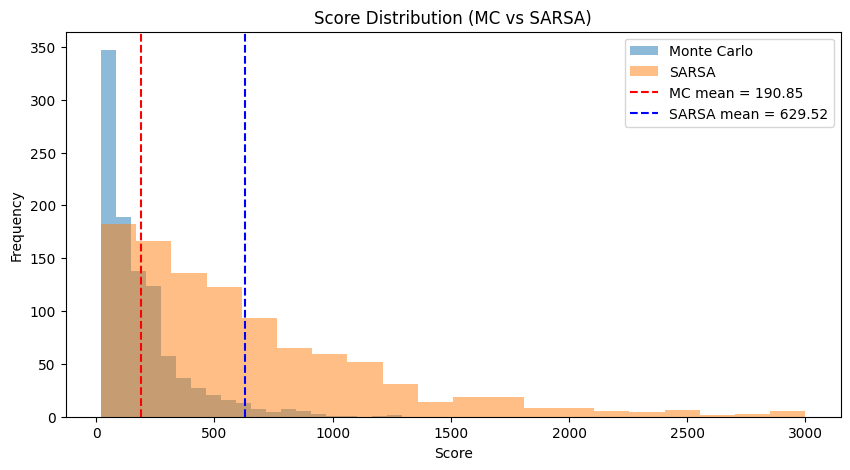

In [62]:
utils.plot_score(n_runs = 1_000, env =  env, agent_mc = agent_mc, agent_sarsa = agent_sarsa)    

## Parameters sweep 

Compare the sensitivity to $\epsilon$

Training MC:   0%|          | 0/25000 [00:00<?, ?it/s]

Testing: 100%|██████████| 1000/1000 [00:14<00:00, 66.76it/s]


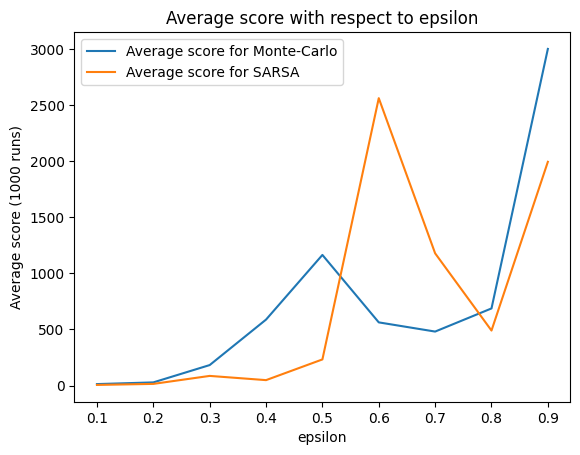

In [ ]:
utils.compare_hyperparameters(env, agents=[agent_mc, agent_sarsa], num_episodes=25_000, 
                              str_parameter="epsilon", range_parameter=np.arange(0.1, 1, 0.1), n_runs = 1_000)

Compare the sensitivity to $\gamma$

Testing: 100%|██████████| 100/100 [00:00<00:00, 905.14it/s]


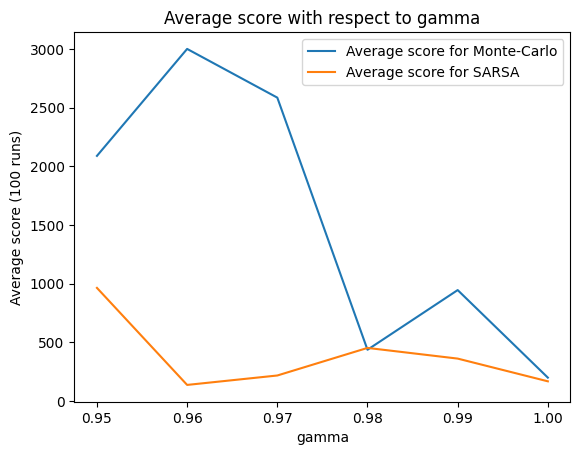

In [77]:
utils.compare_hyperparameters(env, agents=[agent_mc, agent_sarsa], num_episodes=25_000, 
                              str_parameter="gamma", range_parameter=np.arange(0.95, 1, 0.01), n_runs = 100)

Compare the sensitivity to $\alpha$

Testing: 100%|██████████| 1000/1000 [00:02<00:00, 427.89it/s]


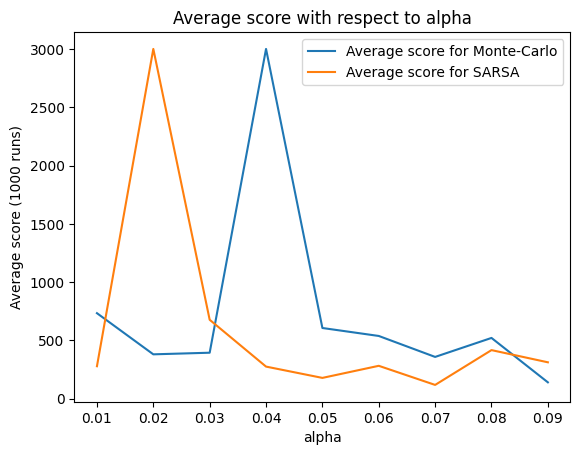

In [75]:
utils.compare_hyperparameters(env, agents=[agent_mc, agent_sarsa], num_episodes=25_000, 
                              str_parameter="alpha", range_parameter=np.arange(0.01, 0.1, 0.01), n_runs = 1_000)

## Domain adaptation, train on the classical env

In [70]:
# Train both agents on the regular setup

env = gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 4)

num_episode = 25_000

obs, _ = env.reset()
agent_mc = MonteCarloControlAgent(action_space_shape = env.action_space.n, alpha = 0.005, gamma=0.99, epsilon=0.8)
agent_mc.train(env = env, num_episodes = num_episode)

obs, _ = env.reset()
agent_sarsa = SarsaLambdaAgent(action_space_shape = env.action_space.n, gamma=0.99, alpha=0.005, epsilon=0.7, lam=0.9)
agent_sarsa.train(env = env, num_episodes = num_episode)

Training SARSA: 100%|██████████| 25000/25000 [00:13<00:00, 1883.69it/s]


## Test on unseen envs (one easier and one harder)

Testing: 100%|██████████| 1000/1000 [00:23<00:00, 43.23it/s]


Mean score for MC : 3000.0
Mean score for SARSA : 3000.0
STD for MC : 0.0
STD for SARSA : 0.0


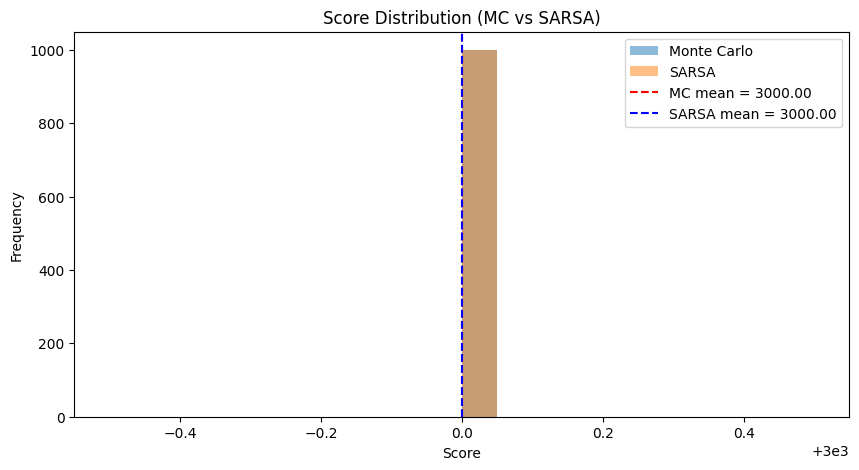

Testing: 100%|██████████| 1000/1000 [00:12<00:00, 80.49it/s]


Mean score for MC : 30.77
Mean score for SARSA : 1676.697
STD for MC : 21.911802755592703
STD for SARSA : 1051.1262061194175


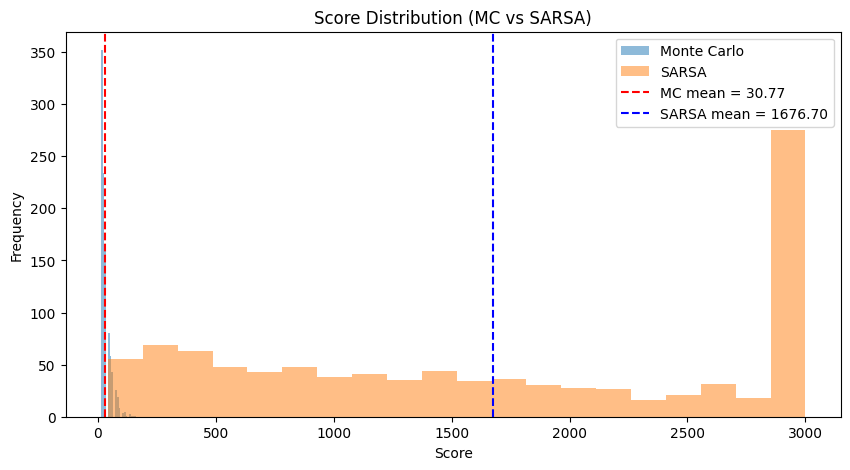

In [ ]:
easy_env = gym.make('TextFlappyBird-v0', height = 10, width = 20, pipe_gap = 7)
hard_env = gym.make('TextFlappyBird-v0', height = 10, width = 20, pipe_gap = 3)

utils.plot_score(n_runs = 1_000, env =  easy_env, agent_mc = agent_mc, agent_sarsa = agent_sarsa) 
utils.plot_score(n_runs = 1_000, env =  hard_env, agent_mc = agent_mc, agent_sarsa = agent_sarsa) 